# NYISO Solar Forecasting: Physics-Informed Feature Engineering for Residual Learning

## Imports and Configuration

In [53]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [54]:
repo_root = Path.home() / "Documents" / "Coding" / "ML_NYISOSolarForecast"

data_root = repo_root / "data"
processed_dir = data_root / "processed"

merged_out = processed_dir / "03_merged_data.csv"

split_date = pd.Timestamp("2024-07-01 00:00:00+00:00")

## Data Load and Schema Standardization

In [55]:
df = pd.read_csv(merged_out, low_memory=False)

df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

df["time_stamp"] = pd.to_datetime(df["time_stamp"], utc=True, errors="coerce")

if "time" in df.columns:
    df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
    same_time_mask = (df["time"] == df["time_stamp"]) | (
        df["time"].isna() & df["time_stamp"].isna()
    )
    if bool(same_time_mask.all()):
        df = df.drop(columns=["time"])

numeric_cols = [
    "actual_mw",
    "forecast_mw",
    "capacity_mw",
    "temperature_2m",
    "surface_pressure",
    "cloud_cover",
    "windspeed_10m",
    "shortwave_radiation",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["zone_name"] = df["zone_name"].astype(str).str.strip().str.upper()

## Target Definition and Time Context

In [56]:
df["time_local"] = df["time_stamp"].dt.tz_convert("America/New_York")

df["year_from_ts"] = df["time_local"].dt.year
df["month_local"] = df["time_local"].dt.month
df["dayofweek_local"] = df["time_local"].dt.dayofweek
df["hour_local"] = df["time_local"].dt.hour

df["is_weekend"] = df["dayofweek_local"].isin([5, 6]).astype(int)
df["is_daylight_proxy"] = (df["shortwave_radiation"] > 0).astype(int)

In [57]:
df["forecast_error_mw"] = df["actual_mw"] - df["forecast_mw"]
df["absolute_error_mw"] = (df["actual_mw"] - df["forecast_mw"]).abs()

df["smape"] = np.where(
    (df["actual_mw"].abs() + df["forecast_mw"].abs()) > 0,
    200 * df["absolute_error_mw"] / (df["actual_mw"].abs() + df["forecast_mw"].abs()),
    np.nan
)

## System-Level Modeling Table

In [58]:
df_system = (
    df[df["zone_name"] == "SYSTEM"]
    .copy()
    .sort_values("time_stamp")
    .reset_index(drop=True)
)

print("System Shape:", df_system.shape)
print("System Time Range:", df_system["time_stamp"].min(), "to", df_system["time_stamp"].max())

System Shape: (42455, 21)
System Time Range: 2020-11-17 05:00:00+00:00 to 2025-09-21 03:00:00+00:00


## Physics-Informed Feature Construction

### Cyclic solar-time features
solar gen is periodic with 24 hours and 365 days, sin(theta) = sin((2*pi*t)/T)

In [59]:
df_system["dayofyear_local"] = df_system["time_local"].dt.dayofyear
df_system["weekofyear_local"] = df_system["time_local"].dt.isocalendar().week.astype(int)

df_system["hour_sin"] = np.sin(2 * np.pi * df_system["hour_local"] / 24)
df_system["hour_cos"] = np.cos(2 * np.pi * df_system["hour_local"] / 24)

df_system["month_sin"] = np.sin(2 * np.pi * df_system["month_local"] / 12)
df_system["month_cos"] = np.cos(2 * np.pi * df_system["month_local"] / 12)

df_system["dayofyear_sin"] = np.sin(2 * np.pi * df_system["dayofyear_local"] / 365.25)
df_system["dayofyear_cos"] = np.cos(2 * np.pi * df_system["dayofyear_local"] / 365.25)

### Solar regime features

In [60]:
df_system["is_morning_ramp"] = df_system["hour_local"].between(6, 9).astype(int)
df_system["is_midday"] = df_system["hour_local"].between(10, 14).astype(int)
# df_system["is_evening_ramp"] = df_system["hour_local"].between(15, 18).astype(int)
df_system["is_night"] = (df_system["is_daylight_proxy"] == 0).astype(int)

### Understanding Capacity 
capacity ratio is forecast/installed cap

## Physics-informed interactions
PV depends on irradiance, temp, and how clouds move
P= f(G,T,C)

In [62]:
df_system["forecast_mw_log1p"] = np.log1p(df_system["forecast_mw"].clip(lower=0))
df_system["shortwave_radiation_log1p"] = np.log1p(df_system["shortwave_radiation"].clip(lower=0))

In [63]:
interaction_features = pd.DataFrame(index=df_system.index)

interaction_features["forecast_x_hour_sin"] = df_system["forecast_mw"] * df_system["hour_sin"]
interaction_features["forecast_x_hour_cos"] = df_system["forecast_mw"] * df_system["hour_cos"]

interaction_features["shortwave_x_cloud"] = (
    df_system["shortwave_radiation"] * (df_system["cloud_cover"] / 100.0)
)

interaction_features["shortwave_x_temp"] = (
    df_system["shortwave_radiation"] * df_system["temperature_2m"]
)

df_system = pd.concat([df_system, interaction_features], axis=1)

### Rolling Windows and Change Features

In [64]:
rolling_features = {}

rolling_features["forecast_roll_mean_3"] = (
    df_system["forecast_mw"].shift(1).rolling(3, min_periods=1).mean()
)

rolling_features["shortwave_roll_mean_3"] = (
    df_system["shortwave_radiation"].shift(1).rolling(3, min_periods=1).mean()
)
rolling_features["forecast_roll_mean_24"] = (
    df_system["forecast_mw"].shift(1).rolling(24, min_periods=1).mean()
)

rolling_features["shortwave_roll_mean_24"] = (
    df_system["shortwave_radiation"].shift(1).rolling(24, min_periods=1).mean()
)

rolling_df = pd.DataFrame(rolling_features)
df_system = pd.concat([df_system, rolling_df], axis=1)

df_system["forecast_diff_1"] = df_system["forecast_mw"].diff(1)
df_system["shortwave_diff_1"] = df_system["shortwave_radiation"].diff(1)
df_system["shortwave_ramp_abs"] = df_system["shortwave_diff_1"].abs()

## Data Quality and Missingness Diagnostics

In [65]:
feature_missing_summary = (
    pd.DataFrame({
        "column": df_system.columns,
        "dtype": [str(df_system[c].dtype) for c in df_system.columns],
        "missing_count": [df_system[c].isna().sum() for c in df_system.columns],
    })
        
    .assign(missing_pct=lambda x: 100 * x["missing_count"] / len(df_system))
    .sort_values(["missing_count", "column"], ascending=[False, True])
)

feature_missing_summary.head(50)

,column,dtype,missing_count,missing_pct
4,capacity_mw,float64,23903,56.301967
20,smape,float64,18910,44.541279
19,absolute_error_mw,float64,1000,2.355435
18,forecast_error_mw,float64,1000,2.355435
2,actual_mw,float64,712,1.677070
42,forecast_diff_1,float64,301,0.708986
3,forecast_mw,float64,288,0.678365
32,forecast_mw_log1p,float64,288,0.678365
35,forecast_x_hour_cos,float64,288,0.678365
34,forecast_x_hour_sin,float64,288,0.678365


## Final Feature Set Definition
The target is the residual, the error. Also columns that could cause leakage needs to be dropped.

In [66]:
target = "forecast_error_mw"

drop_cols = [
    "actual_mw",
    "absolute_error_mw",
    "smape",
    
    "time_stamp",
    "time_local",
    "date_local",
    "zone_name",
    "forecast_error_mw",
    "capacity_mw",
    
    "year",
    "weekofyear_local",             
    "month_local",                
    "dayofweek_local",     
    "hour_local",            
    "is_weekend",          
    "is_night",            
 
]

drop_cols_existing = [c for c in drop_cols if c in df_system.columns]
feature_cols = [c for c in df_system.columns if c not in drop_cols_existing]

final_feature_cols = [
    "forecast_mw",
    "temperature_2m",
    "surface_pressure",
    "cloud_cover",
    "windspeed_10m",
    "shortwave_radiation",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "dayofyear_sin",
    "forecast_x_hour_sin",
    "forecast_x_hour_cos",
    "shortwave_x_cloud",
    "shortwave_x_temp",
    "forecast_roll_mean_3",
    "shortwave_roll_mean_3",
    "forecast_roll_mean_24",
    "shortwave_roll_mean_24",
    "forecast_diff_1",
    "shortwave_diff_1",
    "shortwave_ramp_abs",
    "is_morning_ramp",
    "is_midday",
]

final_feature_cols = [c for c in final_feature_cols if c in df_system.columns]

X = df_system[final_feature_cols].copy()
y = df_system[target].copy()

In [67]:
print("\nTarget:", target)
print("Number of Features:", len(final_feature_cols))
print("Feature Columns:")
print(final_feature_cols)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nX dtypes:")
print(X.dtypes.sort_index())

print("\nTop NaN Counts in X:")
print(X.isna().sum().sort_values(ascending=False).head(30))

print("\nTarget NaN Count:")
print(y.isna().sum())

print("\nEvaluation Columns NaN Counts:")
print(df_system[["actual_mw", "forecast_mw", target]].isna().sum())


Target: forecast_error_mw
Number of Features: 24
Feature Columns:
['forecast_mw', 'temperature_2m', 'surface_pressure', 'cloud_cover', 'windspeed_10m', 'shortwave_radiation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'forecast_x_hour_sin', 'forecast_x_hour_cos', 'shortwave_x_cloud', 'shortwave_x_temp', 'forecast_roll_mean_3', 'shortwave_roll_mean_3', 'forecast_roll_mean_24', 'shortwave_roll_mean_24', 'forecast_diff_1', 'shortwave_diff_1', 'shortwave_ramp_abs', 'is_morning_ramp', 'is_midday']

X shape: (42455, 24)
y shape: (42455,)

X dtypes:
cloud_cover                 int64
dayofyear_sin             float64
forecast_diff_1           float64
forecast_mw               float64
forecast_roll_mean_24     float64
forecast_roll_mean_3      float64
forecast_x_hour_cos       float64
forecast_x_hour_sin       float64
hour_cos                  float64
hour_sin                  float64
is_midday                   int64
is_morning_ramp             int64
month_cos         

## Train/Test Split 

In [68]:
train_time_mask = df_system["time_stamp"] < split_date
test_time_mask = df_system["time_stamp"] >= split_date

train_model_mask = train_time_mask & y.notna()
test_model_mask = (
    test_time_mask
    & y.notna()
    & df_system["actual_mw"].notna()
    & df_system["forecast_mw"].notna()
)

X_train = X.loc[train_model_mask].copy()
X_test = X.loc[test_model_mask].copy()

y_train = y.loc[train_model_mask].copy()
y_test = y.loc[test_model_mask].copy()

baseline_actual_test = df_system.loc[test_model_mask, "actual_mw"].copy()
baseline_forecast_test = df_system.loc[test_model_mask, "forecast_mw"].copy()

print("Split Date:", split_date)
print("Train Time Rows:", int(train_time_mask.sum()))
print("Test Time Rows:", int(test_time_mask.sum()))

print("\nX_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]
assert baseline_actual_test.shape[0] == baseline_forecast_test.shape[0] == y_test.shape[0]

df_system["dataset_split"] = np.where(
    df_system["time_stamp"] < split_date,
    "train",
    "test",
)

Split Date: 2024-07-01 00:00:00+00:00
Train Time Rows: 31723
Test Time Rows: 10732

X_train Shape: (30921, 24)
X_test Shape: (10534, 24)
y_train Shape: (30921,)
y_test Shape: (10534,)


## Final Feature Diagnostics

In [69]:
feature_diagnostics = pd.DataFrame({
    "feature": X_train.columns,
    "dtype": [str(X_train[c].dtype) for c in X_train.columns],
    "missing_train": [int(X_train[c].isna().sum()) for c in X_train.columns],
    "missing_train_pct": [100 * X_train[c].isna().mean() for c in X_train.columns],
    "nunique_train": [X_train[c].nunique(dropna=True) for c in X_train.columns],
    "std_train": [X_train[c].std(skipna=True) for c in X_train.columns],
})

feature_diagnostics = feature_diagnostics.sort_values(
    ["missing_train_pct", "nunique_train", "feature"],
    ascending=[False, True, True]
).reset_index(drop=True)

print("\nFeature Diagnostics:")
print(feature_diagnostics)


Feature Diagnostics:
                   feature    dtype  missing_train  missing_train_pct  \
0    forecast_roll_mean_24  float64             11           0.035575   
1          forecast_diff_1  float64             11           0.035575   
2     forecast_roll_mean_3  float64             11           0.035575   
3       shortwave_ramp_abs  float64              1           0.003234   
4         shortwave_diff_1  float64              1           0.003234   
5    shortwave_roll_mean_3  float64              1           0.003234   
6   shortwave_roll_mean_24  float64              1           0.003234   
7                is_midday    int64              0           0.000000   
8          is_morning_ramp    int64              0           0.000000   
9                month_cos  float64              0           0.000000   
10               month_sin  float64              0           0.000000   
11                hour_cos  float64              0           0.000000   
12                hour_sin  f

In [70]:
corr_input = X_train.copy()
corr_input = corr_input.fillna(corr_input.median(numeric_only=True))

corr_matrix = corr_input.corr(numeric_only=True).abs()

high_corr_pairs = []
cols = corr_matrix.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        corr_val = corr_matrix.iloc[i, j]
        if corr_val >= 0.98:
            high_corr_pairs.append((cols[i], cols[j], corr_val))

high_corr_pairs_df = pd.DataFrame(
    high_corr_pairs,
    columns=["feature_1", "feature_2", "abs_corr"]
).sort_values("abs_corr", ascending=False)

print("\nHigh-Correlation Pairs (|corr| >= 0.98):")
print(high_corr_pairs_df if len(high_corr_pairs_df) > 0 else "nothing found")


High-Correlation Pairs (|corr| >= 0.98):
nothing found


## Model-Ready Dataset Assembly

In [71]:
base_output_cols = [
    "time_stamp",
    "time_local",
    "zone_name",
    "dataset_split",
    "actual_mw",
    "forecast_mw",
    "forecast_error_mw",
]

ordered_cols = []
for c in base_output_cols + final_feature_cols:
    if c not in ordered_cols:
        ordered_cols.append(c)

model_ready_df = df_system.loc[
    y.notna() & df_system["forecast_mw"].notna(),
    ordered_cols
].copy()

print("\nModel-ready Shape:", model_ready_df.shape)
print("Model-ready Columns:")
print(model_ready_df.columns.tolist())
print(model_ready_df.head())

model_ready_out = processed_dir / "04_system_model_ready_data.csv"
print("\nOutput Path:", model_ready_out)


Model-ready Shape: (41455, 30)
Model-ready Columns:
['time_stamp', 'time_local', 'zone_name', 'dataset_split', 'actual_mw', 'forecast_mw', 'forecast_error_mw', 'temperature_2m', 'surface_pressure', 'cloud_cover', 'windspeed_10m', 'shortwave_radiation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'forecast_x_hour_sin', 'forecast_x_hour_cos', 'shortwave_x_cloud', 'shortwave_x_temp', 'forecast_roll_mean_3', 'shortwave_roll_mean_3', 'forecast_roll_mean_24', 'shortwave_roll_mean_24', 'forecast_diff_1', 'shortwave_diff_1', 'shortwave_ramp_abs', 'is_morning_ramp', 'is_midday']
                 time_stamp                time_local zone_name dataset_split  \
0 2020-11-17 05:00:00+00:00 2020-11-17 00:00:00-05:00    SYSTEM         train   
1 2020-11-17 06:00:00+00:00 2020-11-17 01:00:00-05:00    SYSTEM         train   
2 2020-11-17 07:00:00+00:00 2020-11-17 02:00:00-05:00    SYSTEM         train   
3 2020-11-17 08:00:00+00:00 2020-11-17 03:00:00-05:00    SYSTEM         tra

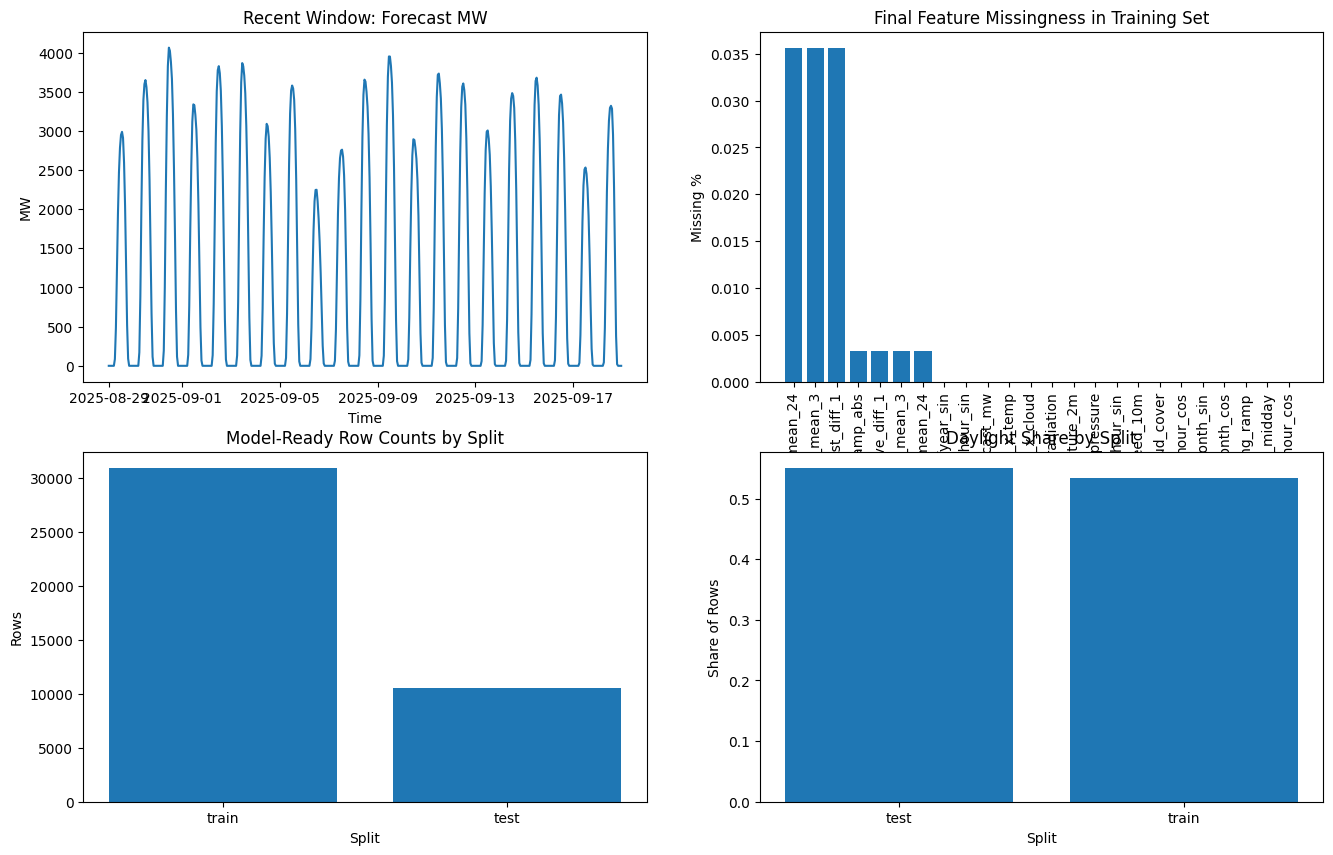

In [72]:
plot_df = model_ready_df.copy()

recent_window = plot_df.tail(min(24 * 21, len(plot_df))).copy()

missing_plot_df = (
    feature_diagnostics[["feature", "missing_train_pct"]]
    .sort_values("missing_train_pct", ascending=False)
    .reset_index(drop=True)
)

split_counts = (
    model_ready_df["dataset_split"]
    .value_counts()
    .rename_axis("dataset_split")
    .reset_index(name="row_count")
)

daylight_share = (
    model_ready_df.assign(is_daylight=(model_ready_df["shortwave_radiation"] > 0).astype(int))
    .groupby("dataset_split", as_index=False)["is_daylight"]
    .mean()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(recent_window["time_local"], recent_window["forecast_mw"])
axes[0, 0].set_title("Recent Window: Forecast MW")
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("MW")

axes[0, 1].bar(missing_plot_df["feature"], missing_plot_df["missing_train_pct"])
axes[0, 1].set_title("Final Feature Missingness in Training Set")
axes[0, 1].set_xlabel("Feature")
axes[0, 1].set_ylabel("Missing %")
axes[0, 1].tick_params(axis="x", rotation=90)

axes[1, 0].bar(split_counts["dataset_split"], split_counts["row_count"])
axes[1, 0].set_title("Model-Ready Row Counts by Split")
axes[1, 0].set_xlabel("Split")
axes[1, 0].set_ylabel("Rows")

axes[1, 1].bar(daylight_share["dataset_split"], daylight_share["is_daylight"])
axes[1, 1].set_title("Daylight Share by Split")
axes[1, 1].set_xlabel("Split")
axes[1, 1].set_ylabel("Share of Rows")

plt.show()

In [73]:
model_ready_df.to_csv(model_ready_out, index=False)